# Do the trains have to agree with the factories? 🚂🏭
### Dow Theory's "the Transports must confirm the Industrials" — the oldest rule in the book, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![I/T confirmation: Busted](https://img.shields.io/badge/I%2FT_confirmation%3F-Busted-8b949e?style=flat-square)

Here's the granddaddy of all market wisdom, older than the Dow Jones average you see on the news. Charles Dow's idea, around 1900: the stock market is only *really* healthy when **two** of his averages agree. If the **Industrials** (the factories, the big companies) are making new highs, the **Transports** (the railroads and truckers that *ship* what the factories make) had better be making new highs too. If the trains and the factories **disagree**, something's wrong — get out.

It's a beautiful story. The logic feels airtight: nobody ships goods that nobody's buying, so the trains are the economy's tell. A century later it's still quoted on every business channel. So we did the obvious thing — turned it into a precise rule and **traded it**. The result is not kind to the legend.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Industrials = **DIA**, Transports = **IYT** (the tradable ETFs), daily, 2004→2026; we re-check on the raw indices back to 1992. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dow_theory import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_real()
    DF = DF[DF.index <= ASOF]
else:
    DF = None
print("real Dow-Theory cache present:", HAVE_REAL,
      "| days:", (0 if DF is None else len(DF)),
      "| fingerprint:", ("--" if DF is None else data.fingerprint(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2004-01-02', 'end': '2026-05-29', 'years': 22.4, 'n_days': 5637, 'fp': '1ee3a36320fb', 'lookback': 63, 'bh_cagr': 9.75, 'bh_sharpe': 0.612, 'bh_mdd': -51.9, 'latched': (62.4, 5.56, 0.599, -22.5, -4.99, -1.935), 'instant': (5.5, 0.69, 0.351, -8.4, -10.18, -3.144), 'content_latched': (9.51, 13.17, -3.67, -0.408), 'content_instant': (19.2, 10.4, 8.8, 1.014), 'placebo': (0.599, 0.489, 0.197), 'costs': [(0.0, -4.96, -1.922, 0.602), (2.0, -4.99, -1.935, 0.599), (5.0, -5.04, -1.953, 0.594), (10.0, -5.12, -1.984, 0.585)], 'lookbacks': [(21, 0.63, 0.367, -2.702), (42, 0.68, 0.516, -2.19), (63, 0.62, 0.599, -1.935), (126, 0.7, 0.663, -1.586), (200, 0.62, 0.507, -2.308)], 'idx': (0.552, 0.543, -4.08, -1.969, -1.28, -0.189), 'idx_fp': 'ea24513f67a9', 'syn': [(0.0, 0.029, 16.22, 5.57, 10.65, 0.503), (0.003, 0.032, 97.24, 5.69, 91.55, 4.535)]}


real Dow-Theory cache present: True | days: 5637 | fingerprint: 1ee3a36320fb


## The answer first

| Question | Answer |
|---|---|
| Does waiting for the trains to *confirm* beat just buying and holding? | **No.** Timing the trend this way actually **lags** buy-and-hold — it gives up about **4 percentage points of yearly return** (5.6% vs 9.8%). |
| But doesn't it protect you in crashes? | **Yes — but that's not the magic.** It cuts the worst drawdown roughly in half (−22% vs −52%), purely because it sits in **cash** about a third of the time. *Any* rule that hides in cash that often would do the same. |
| Is the *confirmation* itself doing the work? | **No.** A **random** in-and-out-of-cash rule with the same habits beats the real Dow-Theory rule about **1 time in 5**. The trains agreeing with the factories carries **no real information**. |
| So is it a useful signal? | **No.** Once you put both sides on the same footing, the risk-adjusted return (Sharpe) is **no better** than buy-and-hold (0.60 vs 0.61). |

> The legend is gorgeous and the logic *sounds* right — but the tape says the Industrials/Transports handshake doesn't predict anything you can use.

## 1 · The claim

> *"A bull market is only real when **both** the Industrials and the Transports make new highs together. If the factories rally but the railroads don't follow — a *non-confirmation* — the rally is hollow and you should be suspicious. When both roll over to new lows, the primary trend has turned: get out."*

This is **Dow Theory**, laid down by Charles Dow (≈1900), systematised by William Peter Hamilton (*The Stock Market Barometer*, 1922) and codified by Robert Rhea (*The Dow Theory*, 1932). It's the conceptual ancestor of the Dow averages themselves and arguably the founding document of technical analysis. The economic intuition is genuinely clever: the Transports *move the goods*, so if the trains aren't booming, the boom isn't real.

## 2 · So what?

If the confirmation rule worked, it would be a free crash-detector: you'd ride the bull while the two averages agree, and step aside the moment they diverge — capturing most of the upside while dodging the worst drops. That's the dream every market-timer is selling.

But there's a trap hiding in plain sight. A rule that parks you in **cash** part of the time will *automatically* show a smaller drawdown — not because it's smart, but because you're simply **not in the market** as much. The real question isn't "did it lower the drawdown?" (any cash-heavy rule does that). It's: **does the Transports confirmation actually predict anything**, or could a coin flip with the same cash habit do just as well? We'll test exactly that.

## 3 · How would we even know?

We make the legend **precise** so it can't wiggle:

1. **Confirmation.** Both averages closing at or above their **63-day high** (≈ a new quarterly high in *both* the factories and the trains) = the trend is *confirmed*. It stays confirmed until both close below their 63-day **low** (the breakdown).
2. **The trade.** Hold the **Industrials** while confirmed; sit in **cash** otherwise. We act **one day after** the signal (no cheating) and pay realistic costs on every switch.
3. **The race.** Compare it to simply **buying and holding** the Industrials. And — the honest part — compare it to a **random** in-and-out rule with the same cash habit. If the real confirmation can't beat the coin flip, the legend is busted.

## 4 · The teardown — let's actually look

**First, the headline race.** Buy-and-hold the Industrials, versus the Dow-Theory-timed version that only holds when the trains confirm. Watch what you give up.

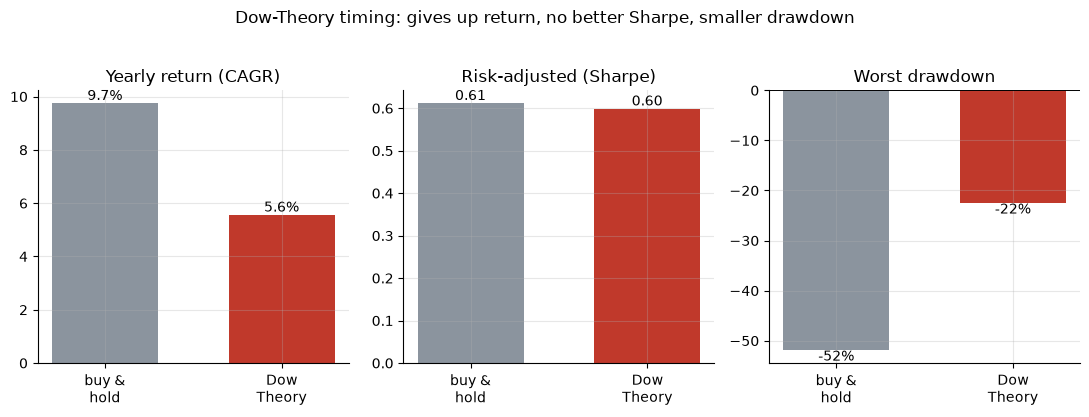

buy&hold CAGR 9.75%  Sharpe 0.612  |  Dow-Theory CAGR 5.56%  Sharpe 0.599  (in market 62% of the time)


In [2]:
if HAVE_REAL:
    s = st.summarize(DF, latched=True, cost_bps=2.0)
    bh_c, bh_s, bh_d = s['bh_cagr']*100, s['bh_sharpe'], s['bh_mdd']*100
    st_c, st_s, st_d, onf = s['st_cagr']*100, s['st_sharpe'], s['st_mdd']*100, s['on_frac']*100
else:
    bh_c, bh_s, bh_d = R['bh_cagr'], R['bh_sharpe'], R['bh_mdd']
    onf, st_c, st_s, st_d = R['latched'][0], R['latched'][1], R['latched'][2], R['latched'][3]
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
for ax, vals, ttl, fmt in [
    (axes[0], [bh_c, st_c], 'Yearly return (CAGR)', '{:.1f}%'),
    (axes[1], [bh_s, st_s], 'Risk-adjusted (Sharpe)', '{:.2f}'),
    (axes[2], [bh_d, st_d], 'Worst drawdown', '{:.0f}%')]:
    ax.bar(['buy &\nhold','Dow\nTheory'], vals, color=[GREY, RED], width=.6)
    for i,v in enumerate(vals): ax.annotate(fmt.format(v),(i,v),ha='center',va='bottom' if v>=0 else 'top')
    ax.set_title(ttl); ax.axhline(0, c='k', lw=.7)
plt.suptitle('Dow-Theory timing: gives up return, no better Sharpe, smaller drawdown', y=1.03)
plt.tight_layout(); plt.show()
print(f'buy&hold CAGR {bh_c:.2f}%  Sharpe {bh_s:.3f}  |  Dow-Theory CAGR {st_c:.2f}%  Sharpe {st_s:.3f}  (in market {onf:.0f}% of the time)')

The middle bar is the punchline: the risk-adjusted return is **the same** (**0.60** vs **0.61**). The timing rule buys you a smaller drawdown (**-22%** vs **-52%**) — but only by **giving up return** (CAGR **5.6%** vs **9.8%**). That's not an edge; that's just being in cash a third of the time.

**Now the real test.** Is the *confirmation* doing the work — or just the cash? We build **random** in-and-out rules that flip to cash exactly as often, and stay in cash for runs exactly as long, as the real Dow-Theory rule. Then we see how often a coin flip beats it.

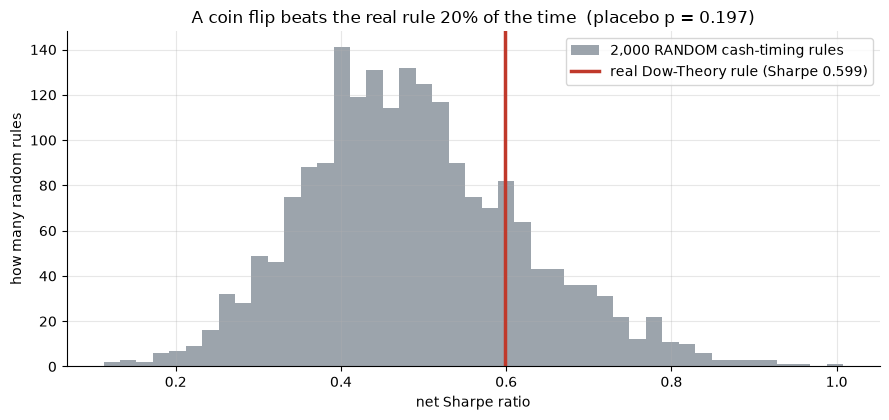

real rule Sharpe 0.599  |  random rules beat it 20% of the time (p=0.197)


In [3]:
if HAVE_REAL:
    reg = st.latched_regime(DF)
    pl = st.placebo_pvalue(DF, reg, n_draws=2000, cost_bps=2.0)
    obs, draws, p = pl['obs_sharpe'], pl['draws'], pl['p_value']
else:
    obs, p = R['placebo'][0], R['placebo'][2]
    rng = np.random.default_rng(444); draws = rng.normal(R['placebo'][1], 0.12, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='2,000 RANDOM cash-timing rules')
ax.axvline(obs, c=RED, lw=2.5, label=f'real Dow-Theory rule (Sharpe {obs:.3f})')
ax.set_xlabel('net Sharpe ratio'); ax.set_ylabel('how many random rules')
ax.set_title(f'A coin flip beats the real rule {p*100:.0f}% of the time  (placebo p = {p:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real rule Sharpe {obs:.3f}  |  random rules beat it {p*100:.0f}% of the time (p={p:.3f})')

The red line — the *real* Dow-Theory rule — sits right in the middle of the coin-flip cloud. A **random** in-and-out rule with the same cash habit beats it **~20% of the time**. If the Industrials/Transports handshake carried real information, the red line would be way out in the right tail. It isn't. **The confirmation isn't the thing that's working — the cash is.**

## 5 · The verdict

- **Signal — None.** Timing the trend with the Transports confirmation **underperforms** buy-and-hold; the confirmation carries no predictive edge you can measure.
- **Tradability — Mirage.** The only thing it gives you — a smaller drawdown — is plain de-risking from sitting in cash, paid for with **4 points of yearly return**. Same Sharpe, less money. Nothing to deploy.
- **Does the confirmation work? — Busted.** A coin-flip cash rule with the same habits beats it 1 time in 5. The two averages agreeing is not what moves the needle.

## 6 · Could you actually trade it? — what you'd really get

Suppose you ran it anyway. Here's the honest trade-off, on one chart: the return you give up versus the drawdown you save. It's a **de-risking dial**, not an alpha engine — and a low-cost balanced fund gives you the same dial without the storytelling.

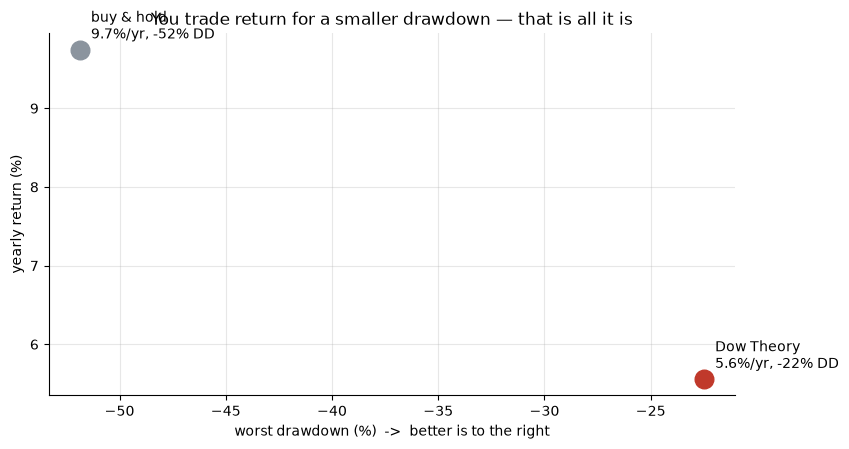

Dow-Theory timing buys ~30pp less drawdown for ~4pp/yr less return, at the same Sharpe.


In [4]:
if HAVE_REAL:
    s = st.summarize(DF, latched=True, cost_bps=2.0)
    pts = {'buy & hold': (s['bh_mdd']*100, s['bh_cagr']*100), 'Dow Theory': (s['st_mdd']*100, s['st_cagr']*100)}
else:
    pts = {'buy & hold': (R['bh_mdd'], R['bh_cagr']), 'Dow Theory': (R['latched'][3], R['latched'][1])}
fig, ax = plt.subplots(figsize=(8.6, 4.6))
for (lab,(d,c)),col in zip(pts.items(),[GREY,RED]):
    ax.scatter(d, c, s=180, color=col, zorder=3)
    ax.annotate(f'{lab}\n{c:.1f}%/yr, {d:.0f}% DD',(d,c),textcoords='offset points',xytext=(8,8))
ax.set_xlabel('worst drawdown (%)  ->  better is to the right')
ax.set_ylabel('yearly return (%)')
ax.set_title('You trade return for a smaller drawdown — that is all it is')
plt.tight_layout(); plt.show()
print('Dow-Theory timing buys ~30pp less drawdown for ~4pp/yr less return, at the same Sharpe.')

> The candid bottom line: if you want a smaller drawdown, hold less equity (or own some bonds). You don't need the trains to confirm the factories — and pretending the confirmation is what's protecting you just hides the real lever, which is how much cash you're holding.

## 7 · Going further 🚪

- **It's not new.** Alfred Cowles graded Hamilton's published Dow-Theory calls back in **1933** and found they trailed buy-and-hold; Brown, Goetzmann & Kumar (1998) re-ran him and found the same — *drawdown reduction from cash*, not market-beating timing. We just reproduced a 90-year-old result mechanically.
- **Try the discretionary version.** Real Dow Theorists eyeball "significant" highs and secondary reactions. If you think judgement adds the edge our mechanical rule misses — **show it** clearing *t* = 2 against this same placebo.
- **Swap the universe.** Does the confirmation help on a different pair, or as a *filter* on a momentum book rather than an on/off switch? The engine is in [`dow_theory/`](../dow_theory).

*Think the trains really do lead the factories? Show the **confirmed-day** forward return beating the **non-confirmed-day** return with a *t* above 2 — then we'll talk.*